## analyzing dispersal weight modeling

In [3]:
from dispersal_weight_generator import *
dispgen = dispersal_weight_generator()
weights_collection = []
topk_w_collection = []
K = 3
C_collection = []
for i in range(3,11,1): # npatch 
    weights_perpatch = []
    incoming_ws_perpatch = []
    C_perpatch = []
    for j in range(100): # sample siz
        sample = dispgen.uniform_dist(i, normalization=2)
        # calculte top k weights and connectivity
        incoming_ws_persample = []
        connectivity_persample = []
        for k in range(sample.shape[0]):
            incoming_w = sample[:,k].copy()
            incoming_w[k] = 0
            topk = np.sort(incoming_w)[-K:]          # K largest
            incoming_ws_persample.append(topk)
            connectivity = np.sum(incoming_w)
            connectivity_persample.append(connectivity)
        incoming_ws_persample = np.concatenate(np.array(incoming_ws_persample))
        connectivity_persample = np.array(connectivity_persample)

        # sample is a diagonally symetric matrix get above diagonals only as an array
        upper_triangular = np.triu(sample, k=1)
        weights = upper_triangular[upper_triangular != 0]
        weights_perpatch.append(weights)
        incoming_ws_perpatch.append(incoming_ws_persample)
        C_perpatch.append(connectivity_persample)
    weights_collection.append(np.concatenate(np.array(weights_perpatch)))
    topk_w_collection.append(np.concatenate(np.array(incoming_ws_perpatch)))
    C_collection.append(np.concatenate(np.array(C_perpatch)))



NameError: name 'topk_w_collection' is not defined

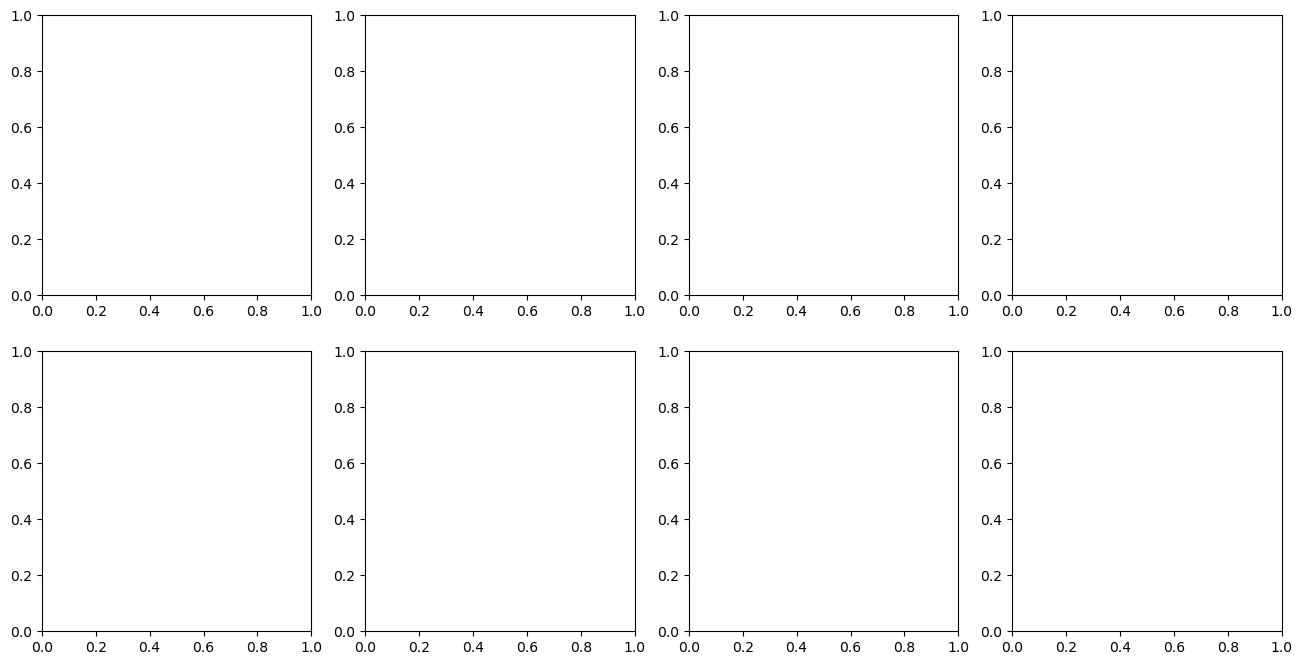

In [2]:
import matplotlib.pyplot as plt
# plot the distribution of top 3 incoming weights per patch in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(topk_w_collection)):
    ax = axes[i]
    ax.hist(topk_w_collection[i], bins=50, density=True)
    ax.set_title(f'top 3 incoming weights per patch. npatch={i+3}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(topk_w_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
# plot the distribution of connectivity in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(C_collection)):
    ax = axes[i]
    ax.hist(C_collection[i], bins=50, density=True)
    ax.set_title(f'Connectivity distribution for npatch={i+3}')
    ax.set_xlabel('Connectivity')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(C_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

NameError: name 'weights_collection' is not defined

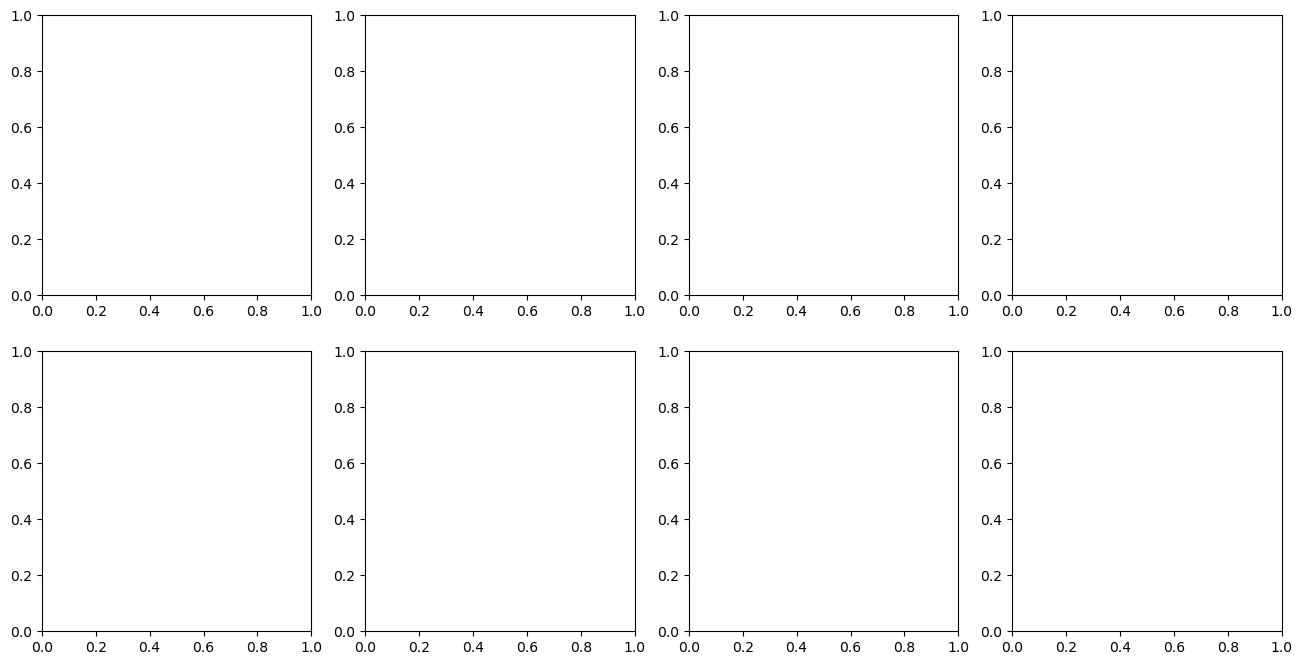

In [ ]:
import matplotlib.pyplot as plt
# plot the distribution of weights for each npatch in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(weights_collection)):
    ax = axes[i]
    ax.hist(weights_collection[i], bins=50, density=True)
    ax.set_title(f'Weight distribution for npatch={i+3}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(weights_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()



2.9088839054172326 0.6983326238057314


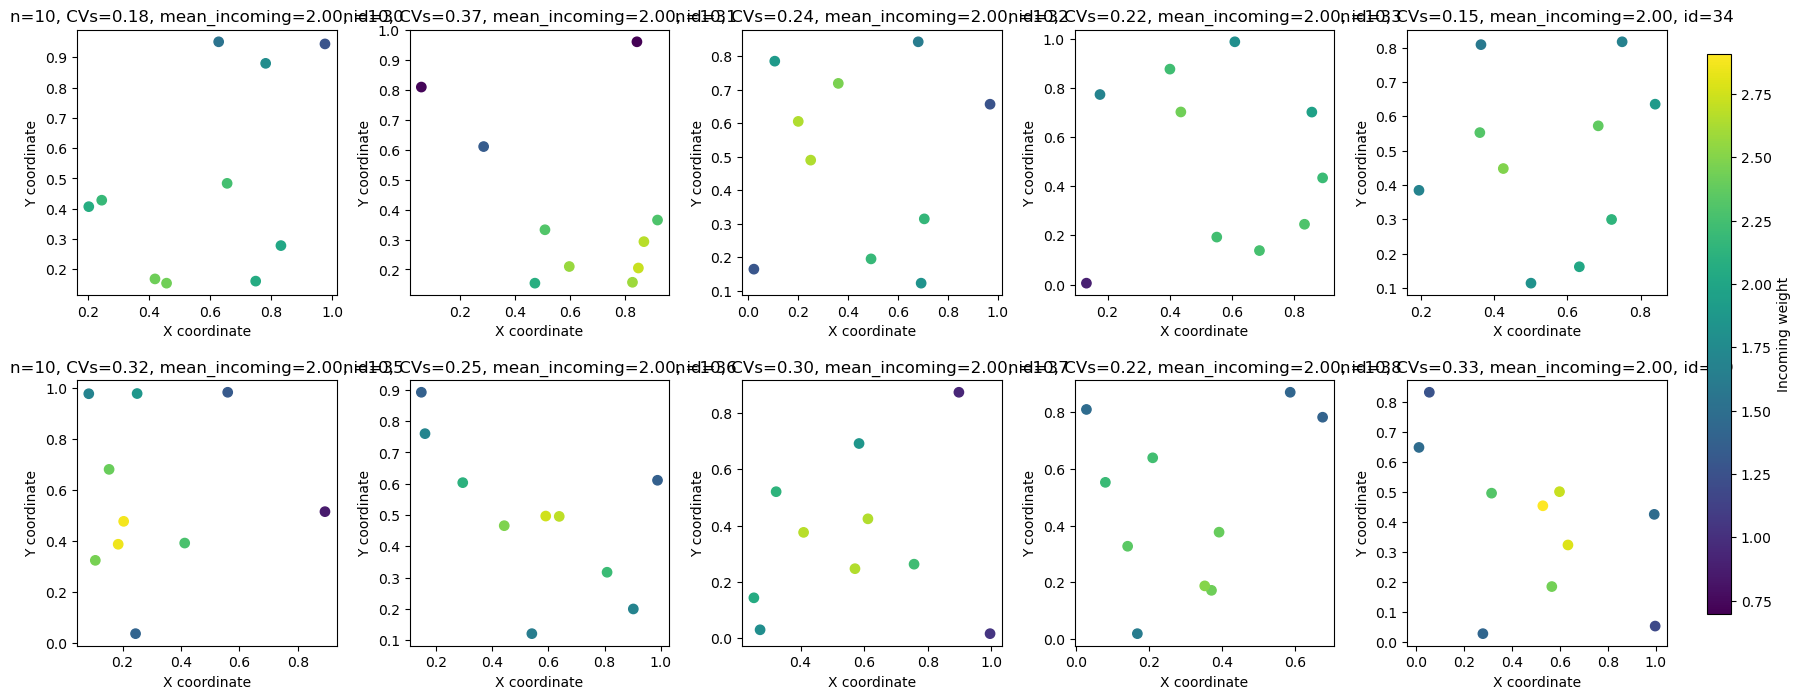

In [4]:
# plot coordinates of the generated patches
import pickle 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
n = 10

def graph_properties(weights):
    # calculate CV of closeness centrality and strength centrality. 
    s = weights.sum(axis=0)  # strength centrality
    # Only take log on positive weights
    closeness = np.full(weights.shape, 0, dtype=float)
    pos = weights > 0
    closeness[pos] = (weights.shape[0]-1)/(-np.log(weights[pos]).sum(axis=0))

    CVc = np.std(closeness)/np.mean(closeness)
    CVs = np.std(s)/np.mean(s)
    return CVc, CVs

with open(f'./dispersal_weights/uniform_dispersal_weights_patchnum{n}.pkl', 'rb') as f:
    weights_collection = pickle.load(f)
with open(f'./dispersal_weights/uniform_dispersal_coords_patchnum{n}.pkl', 'rb') as f:
    coordinates_collection = pickle.load(f)

# plot the coordinates.
id = np.arange(30,40)  # between 0 and 99

# Compute a fixed color scale across all selected samples
incoming_min = np.inf
incoming_max = -np.inf
for sample_id in id:
    incoming_weights = np.sum(weights_collection[sample_id], axis=0)
    incoming_min = min(incoming_min, incoming_weights.min())
    incoming_max = max(incoming_max, incoming_weights.max())
print(incoming_max, incoming_min)
# plot in subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i in range(len(id)):
    # calculate incoming weights for each patch
    weights = weights_collection[id[i]]
    incoming_weights = np.sum(weights, axis=0)
    ax = axes[i]
    coords = coordinates_collection[id[i]]
    CVc, CVs = graph_properties(weights)
    incoming_weights = np.sum(weights, axis=0)
    mean_incoming = np.mean(incoming_weights)
    # color each point by its incoming weight with fixed limits
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=incoming_weights,
        cmap='viridis',
        s=45,
        vmin=incoming_min,
        vmax=incoming_max
    )
    ax.set_title(f'n={n}, CVs={CVs:.2f}, mean_incoming={mean_incoming:.2f}, id={id[i]}')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')

# Reserve space on the right, then draw a dedicated shared colorbar axis
fig.subplots_adjust(right=0.92, wspace=0.28, hspace=0.32)
norm = Normalize(vmin=incoming_min, vmax=incoming_max)
sm = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
fig.colorbar(sm, cax=cbar_ax, label='Incoming weight')

plt.show()

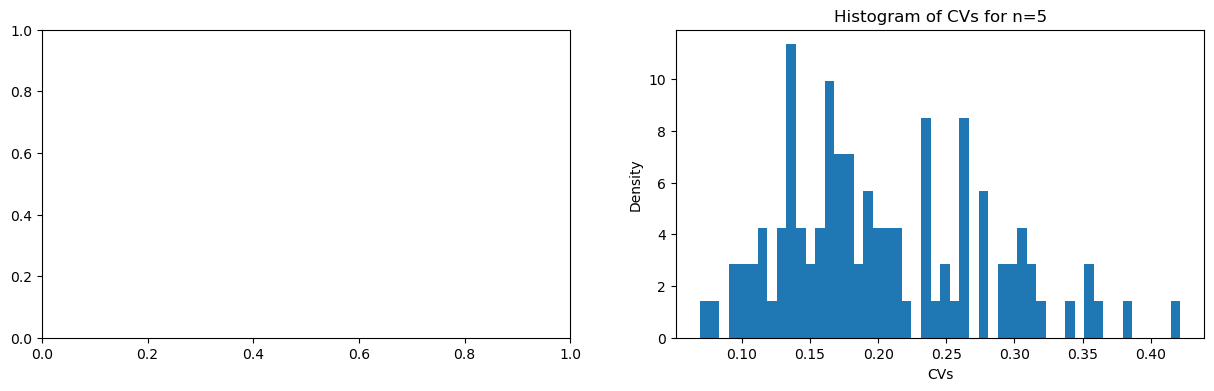

n=5
Percentiles: [ 0 25 50 75 99]
Percentile IDs: [43, 5, 74, 71, 25]
Percentile Values: [0.06930323 0.14608963 0.19093975 0.25957351 0.38523905]
All CVs sorted with their IDs:
[43 64 70 44  9 86 77 65 55 98 47  8 91 23 28 49 12 97  1 27 56 20  0 67
 33  5 60 75 51 80 14 13 17 92 99 22 29 11 73 95 85 39 30 68  3 78 83 26
 42  7 74 82 81 69 84 79 62 35 58 76 48 41 87 32 57 94 18  2 54 24 88 90
 61 34 71 37 19  4 50 36  6 10 16 63 96 40 53 46 31 21 59 38 52 15 72 89
 66 93 25 45]


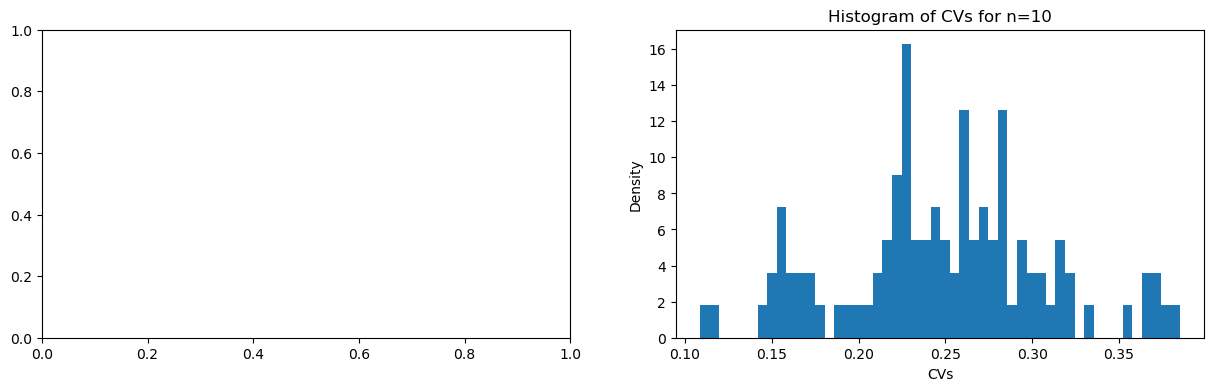

n=10
Percentiles: [ 0 25 50 75 99]
Percentile IDs: [95, 78, 6, 97, 25]
Percentile Values: [0.10858176 0.21944048 0.24716952 0.28390501 0.37606108]
All CVs sorted with their IDs:
[95 19  5 34 77 59 52 16 93 47 81 89 86 65 80 30 56 13 76 64 12 66 44 33
  1 78 38 55 48 14  2 26 99 74 50  4 71 96  9 27 70 63 58 61 11 29 32 36
 28 57  6 87 69 15 72 62 22 21 40 10 51 90 20 18  0 73 54 60 98  3 49 84
 82 41 97  8 91 85 83 43 24 37 88 53 75 42 45 67 46 23 92 35 39  7 94 79
 68 31 25 17]


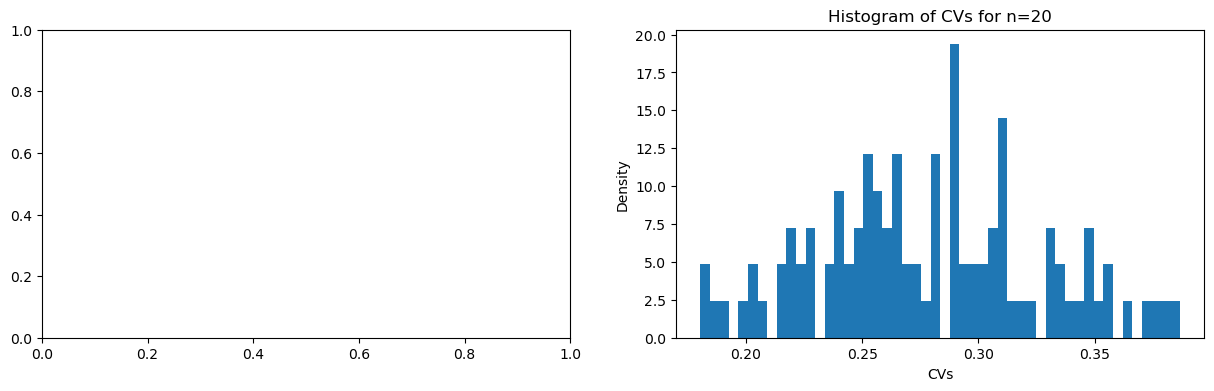

n=20
Percentiles: [ 0 25 50 75 99]
Percentile IDs: [99, 83, 40, 89, 85]
Percentile Values: [0.18019536 0.24375357 0.27898968 0.30945684 0.38187206]
All CVs sorted with their IDs:
[99 92 82 66 47 93 48 61 63 59 37  2 28 22 26 91 67 94  9 25 96 36 33 16
 53 83 54  8 27 46 31 80 73 21 88 10 60 49  5 30 74 45 11 62 43 87 17 13
  1 52 40 71 75 20 72 84 24 79 98 41 32 64 18 81 77 55 39 58 34 38  3 12
 97 42 89 68 23 78 86 51  4 70 76 50 15  0 19 95 29 90 35  6 56 57 69 44
 14  7 85 65]


In [5]:
import pickle
ns = [5,10,20]
for n in ns:
    with open(f'./dispersal_weights/uniform_dispersal_weights_patchnum{n}.pkl', 'rb') as f:
        weights_collection = pickle.load(f)

    CVc_collection = []
    CVs_collection = []
    for i in range(len(weights_collection)):
        # calculate cvs cvc
        weights = weights_collection[i]
        CVc, CVs = graph_properties(weights)
        CVc_collection.append(CVc)
        CVs_collection.append(CVs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    # plot hist of cvs and and scatter of cvs and mean incoming weight
    


    plt.hist(CVs_collection, bins=50, density=True)
    plt.xlabel('CVs')
    plt.ylabel('Density')
    plt.title(f'Histogram of CVs for n={n}')
    plt.show()
    # get IDs at percentile ranks (not first value >= percentile threshold)
    arr = np.asarray(CVs_collection)
    qs = np.array([0, 25, 50, 75, 99])
    percentiles = np.percentile(arr, qs)

    sorted_idx = np.argsort(arr)
    rank_pos = np.rint((qs / 100.0) * (len(arr) - 1)).astype(int)
    percentile_ids = sorted_idx[rank_pos].tolist()
    percentile_values = arr[percentile_ids]

    percentiles, percentile_ids, percentile_values
    print(f'n={n}')
    print(f"Percentiles: {qs}")
    print(f"Percentile IDs: {percentile_ids}")
    print(f"Percentile Values: {percentile_values}")
    # print all from smallest to largest index
    sorted_indices = np.argsort(arr)
    print("All CVs sorted with their IDs:")
    print(sorted_indices)

Note on what dispersal ID to use for low, median, and high centrality based on above cell result.

n=5-> low: 43, median: 74, high: 25

n=10-> low: 95, median: 6, high: 25

n=20-> low: 99, median: 40, high: 85